# Sheep and Wolves Model in Mesa

The current model is from Mesa's own example library: https://mesa.readthedocs.io/latest/examples/advanced/wolf_sheep.html

Citation: ter Hoeven, E., Kwakkel, J., Hess, V., Pike, T., Wang, B., rht, & Kazil, J. (2025). Mesa 3: Agent-based modeling with Python in 2025. Journal of Open Source Software, 10(107), 7668. https://doi.org/10.21105/joss.07668

In [88]:
from mesa.discrete_space import CellAgent, FixedAgent
import math
import mesa
from mesa import Model
from mesa.datacollection import DataCollector
from mesa.discrete_space import OrthogonalVonNeumannGrid, CellAgent, FixedAgent
from mesa.experimental.devs import ABMSimulator


# Agent

In [89]:
from mesa.discrete_space import CellAgent, FixedAgent


class Animal(CellAgent):
    """The base animal class."""

    def __init__(
        self, model, energy=8, p_reproduce=0.04, energy_from_food=4, cell=None
    ):
        """Initialize an animal.

        Args:
            model: Model instance
            energy: Starting amount of energy
            p_reproduce: Probability of reproduction (asexual)
            energy_from_food: Energy obtained from 1 unit of food
            cell: Cell in which the animal starts
        """
        super().__init__(model)
        self.energy = energy
        self.p_reproduce = p_reproduce
        self.energy_from_food = energy_from_food
        self.cell = cell

    def spawn_offspring(self):
        """Create offspring by splitting energy and creating new instance."""
        self.energy /= 2
        self.__class__(
            self.model,
            self.energy,
            self.p_reproduce,
            self.energy_from_food,
            self.cell,
        )

    def feed(self):
        """Abstract method to be implemented by subclasses."""

    def step(self):
        """Execute one step of the animal's behavior."""
        # Move to random neighboring cell
        self.move()

        self.energy -= 1

        # Try to feed
        self.feed()

        # Handle death and reproduction
        if self.energy < 0:
            self.remove()
        elif self.random.random() < self.p_reproduce:
            self.spawn_offspring()


class Sheep(Animal):
    """A sheep that walks around, reproduces (asexually) and gets eaten."""

    def feed(self):
        """If possible, eat grass at current location."""
        grass_patch = next(
            (obj for obj in self.cell.agents if isinstance(obj, GrassPatch)),
            None
        )
        if grass_patch and grass_patch.fully_grown:
            self.energy += self.energy_from_food
            grass_patch.fully_grown = False
            grass_patch.countdown = grass_patch.grass_regrowth_time  # Start countdown

    def move(self):
        """Move towards a cell where there isn't a wolf, and preferably with grown grass."""
        cells_without_wolves = self.cell.neighborhood.select(
            lambda cell: not any(isinstance(obj, Wolf) for obj in cell.agents)
        )
        # If all surrounding cells have wolves, stay put
        if len(cells_without_wolves) == 0:
            return

        # Among safe cells, prefer those with grown grass
        cells_with_grass = cells_without_wolves.select(
            lambda cell: any(
                isinstance(obj, GrassPatch) and obj.fully_grown for obj in cell.agents
            )
        )
        # Move to a cell with grass if available, otherwise move to any safe cell
        target_cells = (
            cells_with_grass if len(cells_with_grass) > 0 else cells_without_wolves
        )
        self.cell = target_cells.select_random_cell()


class Wolf(Animal):
    """A wolf that walks around, reproduces (asexually) and eats sheep."""

    def feed(self):
        """If possible, eat a sheep at current location."""
        sheep = [obj for obj in self.cell.agents if isinstance(obj, Sheep)]
        if sheep:  # If there are any sheep present
            sheep_to_eat = self.random.choice(sheep)
            self.energy += self.energy_from_food
            sheep_to_eat.remove()

    def move(self):
        """Move to a neighboring cell, preferably one with sheep."""
        cells_with_sheep = self.cell.neighborhood.select(
            lambda cell: any(isinstance(obj, Sheep) for obj in cell.agents)
        )
        target_cells = (
            cells_with_sheep if len(cells_with_sheep) > 0 else self.cell.neighborhood
        )
        self.cell = target_cells.select_random_cell()


class GrassPatch(FixedAgent):
    """A patch of grass that grows at a fixed rate and can be eaten by sheep."""

    def __init__(self, model, countdown, grass_regrowth_time, cell):
        """Create a new patch of grass.

        Args:
            model: Model instance
            countdown: Time until grass is fully grown again
            grass_regrowth_time: Time needed to regrow after being eaten
            cell: Cell to which this grass patch belongs
        """
        super().__init__(model)
        self.fully_grown = countdown == 0
        self.countdown = countdown  # Initialize countdown!
        self.grass_regrowth_time = grass_regrowth_time
        self.cell = cell

    def step(self):
        """Regrow grass based on countdown."""
        if not self.fully_grown and self.countdown > 0:
            self.countdown -= 1
            if self.countdown == 0:
                self.fully_grown = True

# model

In [90]:
"""
Wolf-Sheep Predation Model
================================

Replication of the model found in NetLogo:
    Wilensky, U. (1997). NetLogo Wolf Sheep Predation model.
    http://ccl.northwestern.edu/netlogo/models/WolfSheepPredation.
    Center for Connected Learning and Computer-Based Modeling,
    Northwestern University, Evanston, IL.
"""

class WolfSheep(Model):
    """Wolf-Sheep Predation Model.

    A model for simulating wolf and sheep (predator-prey) ecosystem modelling.
    """

    description = (
        "A model for simulating wolf and sheep (predator-prey) ecosystem modelling."
    )

    def __init__(
        self,
        width=20,
        height=20,
        initial_sheep=100,
        initial_wolves=50,
        sheep_reproduce=0.04,
        wolf_reproduce=0.05,
        wolf_gain_from_food=20,
        grass=True,
        grass_regrowth_time=30,
        sheep_gain_from_food=4,
        seed=None,
        simulator: ABMSimulator = None,
    ):
        """Create a new Wolf-Sheep model with the given parameters.

        Args:
            height: Height of the grid
            width: Width of the grid
            initial_sheep: Number of sheep to start with
            initial_wolves: Number of wolves to start with
            sheep_reproduce: Probability of each sheep reproducing each step
            wolf_reproduce: Probability of each wolf reproducing each step
            wolf_gain_from_food: Energy a wolf gains from eating a sheep
            grass: Whether to have the sheep eat grass for energy
            grass_regrowth_time: How long it takes for a grass patch to regrow
                                once it is eaten
            sheep_gain_from_food: Energy sheep gain from grass, if enabled
            seed: Random seed
            simulator: ABMSimulator instance for event scheduling
        """
        super().__init__(seed=seed)

        if simulator is None:
            simulator = ABMSimulator()

        self.simulator = simulator
        self.simulator.setup(self)

        # Initialize model parameters
        self.height = height
        self.width = width
        self.grass = grass

        # Create grid using experimental cell space
        self.grid = OrthogonalVonNeumannGrid(
            [self.height, self.width],
            torus=True,
            capacity=math.inf,
            random=self.random,
        )

        # Set up data collection
        model_reporters = {
            "Wolves": lambda m: len(m.agents_by_type[Wolf]),
            "Sheep": lambda m: len(m.agents_by_type[Sheep]),
        }
        if grass:
            model_reporters["Grass"] = lambda m: len(
                m.agents_by_type[GrassPatch].select(lambda a: a.fully_grown)
            )

        self.datacollector = DataCollector(model_reporters)

        # Create sheep:
        Sheep.create_agents(
            self,
            initial_sheep,
            energy=self.rng.random((initial_sheep,)) * 2 * sheep_gain_from_food,
            p_reproduce=sheep_reproduce,
            energy_from_food=sheep_gain_from_food,
            cell=self.random.choices(self.grid.all_cells.cells, k=initial_sheep),
        )
        # Create Wolves:
        Wolf.create_agents(
            self,
            initial_wolves,
            energy=self.rng.random((initial_wolves,)) * 2 * wolf_gain_from_food,
            p_reproduce=wolf_reproduce,
            energy_from_food=wolf_gain_from_food,
            cell=self.random.choices(self.grid.all_cells.cells, k=initial_wolves),
        )

        # Create grass patches if enabled
        if grass:
            possibly_fully_grown = [True, False]
            for cell in self.grid:
                fully_grown = self.random.choice(possibly_fully_grown)
                countdown = (
                    0 if fully_grown else self.random.randrange(0, grass_regrowth_time)
                )
                GrassPatch(self, countdown, grass_regrowth_time, cell)

        # Collect initial data
        self.running = True
        self.datacollector.collect(self)

    def step(self):
        """Execute one step of the model."""
        # First activate all sheep, then all wolves, both in random order
        self.agents_by_type[Sheep].shuffle_do("step")
        self.agents_by_type[Wolf].shuffle_do("step")

        if self.grass:
            self.agents_by_type[GrassPatch].do("step")

        # Collect data
        self.datacollector.collect(self)

In [91]:
# App

In [92]:
from mesa.visualization import (
    CommandConsole,
    Slider,
    SolaraViz,
    make_plot_component,
    make_space_component,
)


def wolf_sheep_portrayal(agent):
    if agent is None:
        return

    portrayal = {
        "size": 25,
    }

    if isinstance(agent, Wolf):
        portrayal["color"] = "tab:red"
        portrayal["marker"] = "o"
        portrayal["zorder"] = 2
    elif isinstance(agent, Sheep):
        portrayal["color"] = "tab:cyan"
        portrayal["marker"] = "o"
        portrayal["zorder"] = 2
    elif isinstance(agent, GrassPatch):
        if agent.fully_grown:
            portrayal["color"] = "tab:green"
        else:
            portrayal["color"] = "tab:brown"
        portrayal["marker"] = "s"
        portrayal["size"] = 75

    return portrayal

In [93]:
model_params = {
    "seed": {
        "type": "InputText",
        "value": 42,
        "label": "Random Seed",
    },
    "grass": {
        "type": "Select",
        "value": True,
        "values": [True, False],
        "label": "grass regrowth enabled?",
    },
    "grass_regrowth_time": Slider("Grass Regrowth Time", 20, 1, 50),
    "initial_sheep": Slider("Initial Sheep Population", 100, 10, 300),
    "sheep_reproduce": Slider("Sheep Reproduction Rate", 0.04, 0.01, 1.0, 0.01),
    "initial_wolves": Slider("Initial Wolf Population", 10, 5, 100),
    "wolf_reproduce": Slider(
        "Wolf Reproduction Rate",
        0.05,
        0.01,
        1.0,
        0.01,
    ),
    "wolf_gain_from_food": Slider("Wolf Gain From Food Rate", 20, 1, 50),
    "sheep_gain_from_food": Slider("Sheep Gain From Food", 4, 1, 10),
}


def post_process_space(ax):
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def post_process_lines(ax):
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.9))

space_component = make_space_component(
    wolf_sheep_portrayal, draw_grid=False, post_process=post_process_space
)
lineplot_component = make_plot_component(
    {"Wolves": "tab:orange", "Sheep": "tab:cyan", "Grass": "tab:green"},
    post_process=post_process_lines,
)


In [94]:
simulator = ABMSimulator()
model = WolfSheep(simulator=simulator, grass=True)

page = SolaraViz(
    model,
    components=[space_component, lineplot_component, CommandConsole],
    model_params=model_params,
    name="Wolf Sheep",
    simulator=simulator,
)
page  # noqa


Cannot show ipywidgets in text

# Running experiment and getting info
Run an experiment and select some parameter ranges. Find a set of parameter combinations that never leads to extinction of either species. Do this by running experiments with one seed per parameter combination and then analyzing each experiment if either species went extinct. If they did, remove that parameter combination from the list of valid combinations. Repeat until you have a set of parameter combinations that never lead to extinction. Report your findings.

## Remember from last week el farol parameter sweep that that parameter sweeps look something like this
```python
import pandas as pd
params = {"number_of_strategies": [1, 5, 10, 20],
          "memory_size": [1, 5, 10, 20]}

results_5seeds = mesa.batch_run(
    ElfarolModel,
    parameters=params,
    iterations=2, # we now explicitly set seeds to run through
    max_steps=50,
    number_processes=1,
    data_collection_period=1,  # Need to collect every step
    display_progress=True,
)

results_5seeds = pd.DataFrame(results_5seeds)
```

In [95]:
import pandas as pd


# Run you parameter sweep experiment here


# make a DataFrame


  0%|          | 0/1944 [00:00<?, ?it/s]

# Check which ones have are wolf + sheep surviving models


In [96]:
# Save the relevant data from the experiment here

# also save a dataset with only the last step of each run
    # subselect when step = 100


# quick check percentage non-zero


Percentage of runs with non-zero sheep and zero wolves at the end 100 steps: 35.96%


# Plot the ratio of sheep to wolves that seem to lead to more stable outcomes
Create a new column calculating the ratio of initial sheep to initial wolves. Then create another column indicating whether both species survived to the end (Sheep > 0 AND Wolves > 0). Use a boxplot to visualize how this ratio differs between surviving and extinct runs. Finally, use `scipy.stats.ttest_ind()` to statistically test whether the difference in ratios between survived and extinct runs is significant. What does a p-value < 0.05 tell you about the relationship between initial population ratios and ecosystem stability?

```python
from scipy import stats
stats.ttest_ind(x, y)
```

<Figure size 1000x600 with 0 Axes>

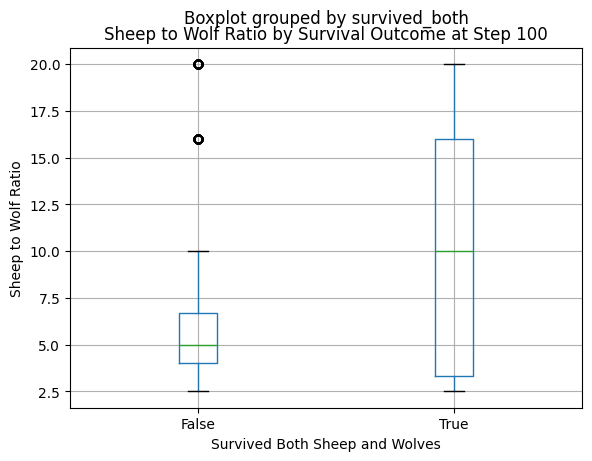


T-test results: t-statistic = 10.0415, p-value = 0.0000


In [97]:
# Make a copy


# What population ratio of sheep to wolves seems to lead to more stable outcomes?


# Plot


# Simple test


# Now lets get the best settings from the previous parameter sweep
Your goal is to find which parameter combination resulted in the most balanced ecosystem at step 100 that you think will show the most stable dynamics. e.g., perhaps you would say that when the number of sheep and wolves are closest to each other at step 100, that this is the most balanced ecosystem. You can calculate this by creating a new column in the dataframe that calculates the absolute difference between the number of sheep and wolves at step 100. Then you can use the `nsmallest()` function to find the row with the smallest difference.

There are other criteria of course that you can think of. Select the one simulation run that you think will be the model with the most stable dynamics for the next experiment.

In [115]:
# save the best settings for experiment 2

# which have the closest 1:1 ratio of sheep to wolves at step 100


,RunId,iteration,Step,initial_sheep,initial_wolves,sheep_reproduce,wolf_reproduce,wolf_gain_from_food,sheep_gain_from_food,grass,grass_regrowth_time,Wolves,Sheep,Grass,Sheep_to_Wolf_ratio,survived_both,sheep_wolf_ratio,ratio_diff_from_1
6968,68,0,100,50,5,0.04,0.1,22,5,True,10,2,2,382,10.0,True,1.0,0.0


# Experiment 2: Testing the Best Settings with Longer Runs
Now that we identified the parameter combination that has some potentially stable dynamics, let's test it more thoroughly. We'll run the simulation with these "best settings" multiple times (5 iterations) and for much longer (500 steps instead of 100) to see if the populations actually remain stable over time.

First, we need to extract the best parameter values from our previous experiment and put them into a format that `mesa.batch_run()` can use. The code below converts each parameter from the `best_settings` row into a list. Then we'll run 5 independent simulations with these same parameters to see how consistent the results are.

**Goal**: Do these "optimal" parameters truly create stable populations, or do the populations still eventually crash?

In [116]:
import pandas as pd
# set params

# Run you parameter sweep experiment here


# make a DataFrame


  0%|          | 0/5 [00:00<?, ?it/s]

# Check again for percentage populations surviving at end of 500 steps

In [100]:
# Save the relevant data from the experiment here

# also save a dataset with only the last step of each run


# quick check percentage non-zero


Percentage of runs with non-zero sheep and zero wolves at the end 500 steps: 0.00%


# Plot time series for experiment 2

Create a plot showing how sheep, wolf, and grass populations change over time for a single simulation run. First, filter your data to select just one run using `RunId == 0` and store it in a variable like `grp`. Then create a figure and plot each population against time:
```python
import matplotlib.pyplot as plt

grp = exp2_df[exp2_df['RunId'] == 0]

plt.figure(figsize=(12, 6))
plt.plot(grp['Step'], grp['Sheep'], label='Sheep', color='tab:cyan')
# Add more plt.plot() lines for Wolves and Grass
```

Use `plt.plot()` for each population, accessing columns like `grp['Step']`, `grp['Sheep']`, etc. Use different colors for each population and add labels so the legend is clear. Don't forget `plt.xlabel()`, `plt.ylabel()`, `plt.legend()`, and `plt.show()`. What patterns do you observe in the oscillations? 

Also inspect the other runID's

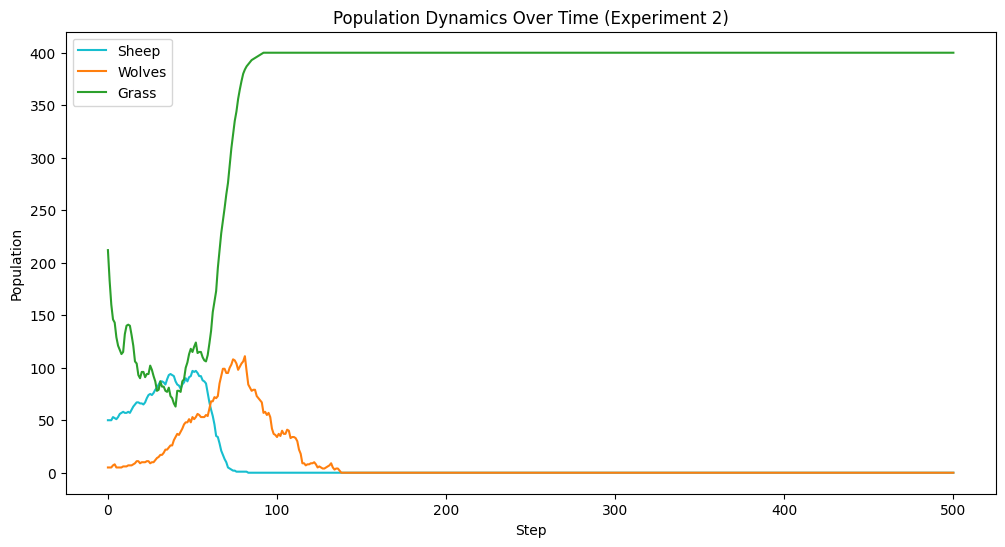

In [113]:
# plot time seires for this experiment

# pick a single run to plot 'RunID' == 0

# plot grass, sheep, wolves over time


# Time series analysis: Detecting oscillation peaks

Use `scipy.signal.find_peaks` (see [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html)) to detect peaks (local maxima) in the sheep and wolf populations over time. First, select a single run from your data using `RunId == 0`. Optionally, to reduce noise, you can smooth the data using `.rolling(window=3).mean()` which averages every 3 consecutive points. Convert the populations to numpy arrays using `.values` so they work with `find_peaks()`. The `distance` parameter in `find_peaks()` controls how far apart peaks must be (try `distance=5` to avoid detecting small fluctuations). 

Example usage:
```python
from scipy.signal import find_peaks
sheep_peaks, _ = find_peaks(sheeppop_timeseries, distance=5) # distance controls how far apart peaks must be
```

Plot the time series with the detected peaks marked as dots using `plt.plot(steps[sheep_peaks], sheep[sheep_peaks], "o")`. Calculate the average time between peaks by taking the differences between consecutive peak positions using array slicing `steps[sheep_peaks][1:] - steps[sheep_peaks][:-1]` and then `.mean()`. This tells you the oscillation period - how long each predator-prey cycle takes!

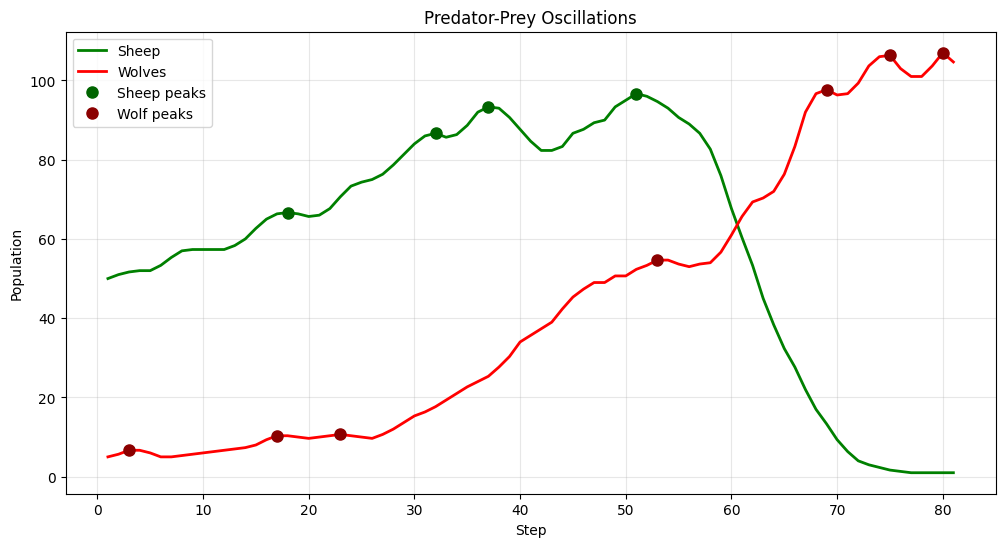

Sheep had 4 peaks
Wolves had 7 peaks
Sheep peak magnitudes: [66.66666667 86.66666667 93.33333333 96.66666667]
Wolf peak magnitudes: [  6.66666667  10.33333333  10.66666667  54.66666667  97.66666667
 106.33333333 107.        ]
Average periodicity between sheep peaks: 11.00 steps
Average periodicity between wolf peaks: 12.83 steps


In [114]:
# Time series analysis
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Pick one run to analyze


# only keep steps where both populations are non-zero

# lets smooth the data a bit with rolling mean

# Get populations as arrays

# Find peaks (high points) in populations


# Plot

# Mark the peaks


# Print simple summary

# print magnitudes of peaks


# calculate the average periodicity between peaks


